# Google Cloud Vision API Deep Dive for Beehive Analysis
** Comprehensive exploration of Vision API capabilities for honeycomb inspection**. 

Optimized for Jupyter Notebook usage

(RUN CELL AT BOTTOM FIRST)


In [4]:
# Display the quick start guide
notebook_quick_start()


    # 🐝 Vision API Explorer - Notebook Quick Start

    ## Setup (Run Once)
    ```python
    # Set your credentials
    credentials_path = "path/to/your-service-account-key.json"

    # Or set environment variable
    import os
    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = credentials_path
    ```

    ## Quick Single Image Analysis
    ```python
    # Analyze one image with minimal output
    explorer, results = quick_analysis('path/to/hive_photo.jpg', verbose=False)
    ```

    ## Compare Multiple Images
    ```python
    # Compare several images side by side
    image_list = ['hive1.jpg', 'hive2.jpg', 'hive3.jpg']
    explorer, df = compare_images(image_list)
    ```

    ## Deep Dive Analysis
    ```python
    # Full analysis with all visualizations
    explorer = BeehiveVisionExplorer(verbose=True)
    results = explorer.analyze_comprehensive('detailed_hive_photo.jpg')
    explorer.visualize_detections('detailed_hive_photo.jpg')

    # Get summary dataframe
    df = explorer.create_summary_dataframe()
    display(df)
    ```

    ## Key Questions to Explore
    - Can it distinguish honey vs brood by color?
    - Does it detect hexagonal patterns?
    - What confidence levels do bee-related labels get?
    - How consistent are results across different lighting?
    

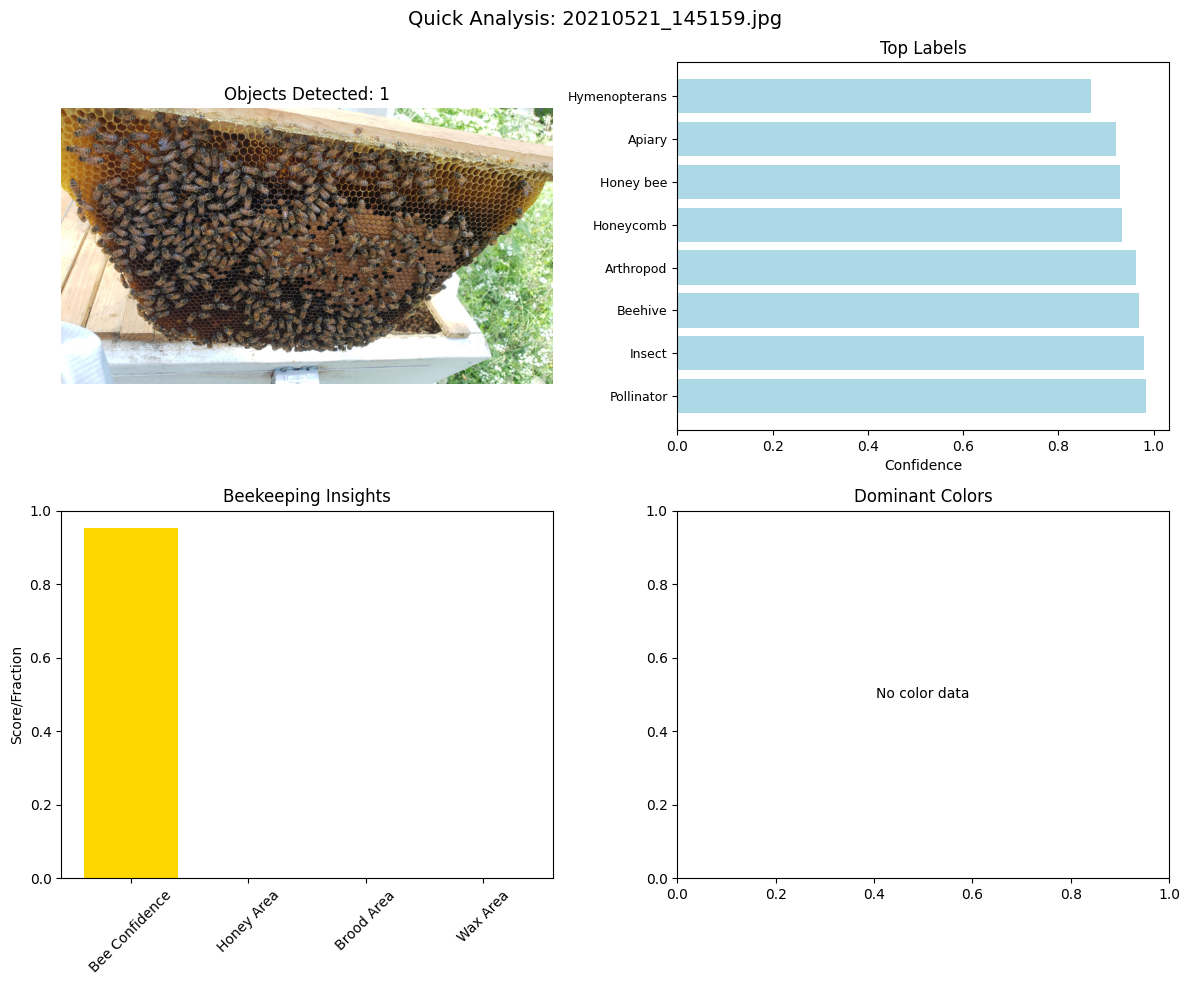


🐝 Key Insights for 20210521_145159.jpg:
   • Bee-related confidence: 0.95
   • Objects detected: 1
   • Top label: Pollinator
   • Label confidence: 0.98


In [8]:
import os
credentials_path = "/Users/bhs/key.json"
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = credentials_path

path2img = "/Users/bhs/Pictures/Bee Photos Over Time/Bees 2021-05-21/20210521_145159.jpg"
# Analyze one image with minimal output
explorer, results = quick_analysis(path2img, verbose=False)



Analyzing 3 images...


,image_name,image_path,objects_detected,labels_count,text_elements,dominant_colors,bee_confidence,honey_area,brood_area,wax_area,top_label,top_label_confidence
0,20210521_145159.jpg,/Users/bhs/Pictures/Bee Photos Over Time/Bees ...,1,10,0,0,0.953360,0,0,0,Pollinator,0.983356
1,PXL_20250501_194435402.jpg,/Users/bhs/Downloads/PXL_20250501_194435402.jpg,0,10,5,0,0.953534,0,0,0,Pollinator,0.985163
2,20250501_194442086.jpg,/Users/bhs/Downloads/20250501_194442086.jpg,1,10,4,0,0.943316,0,0,0,Pollinator,0.981464


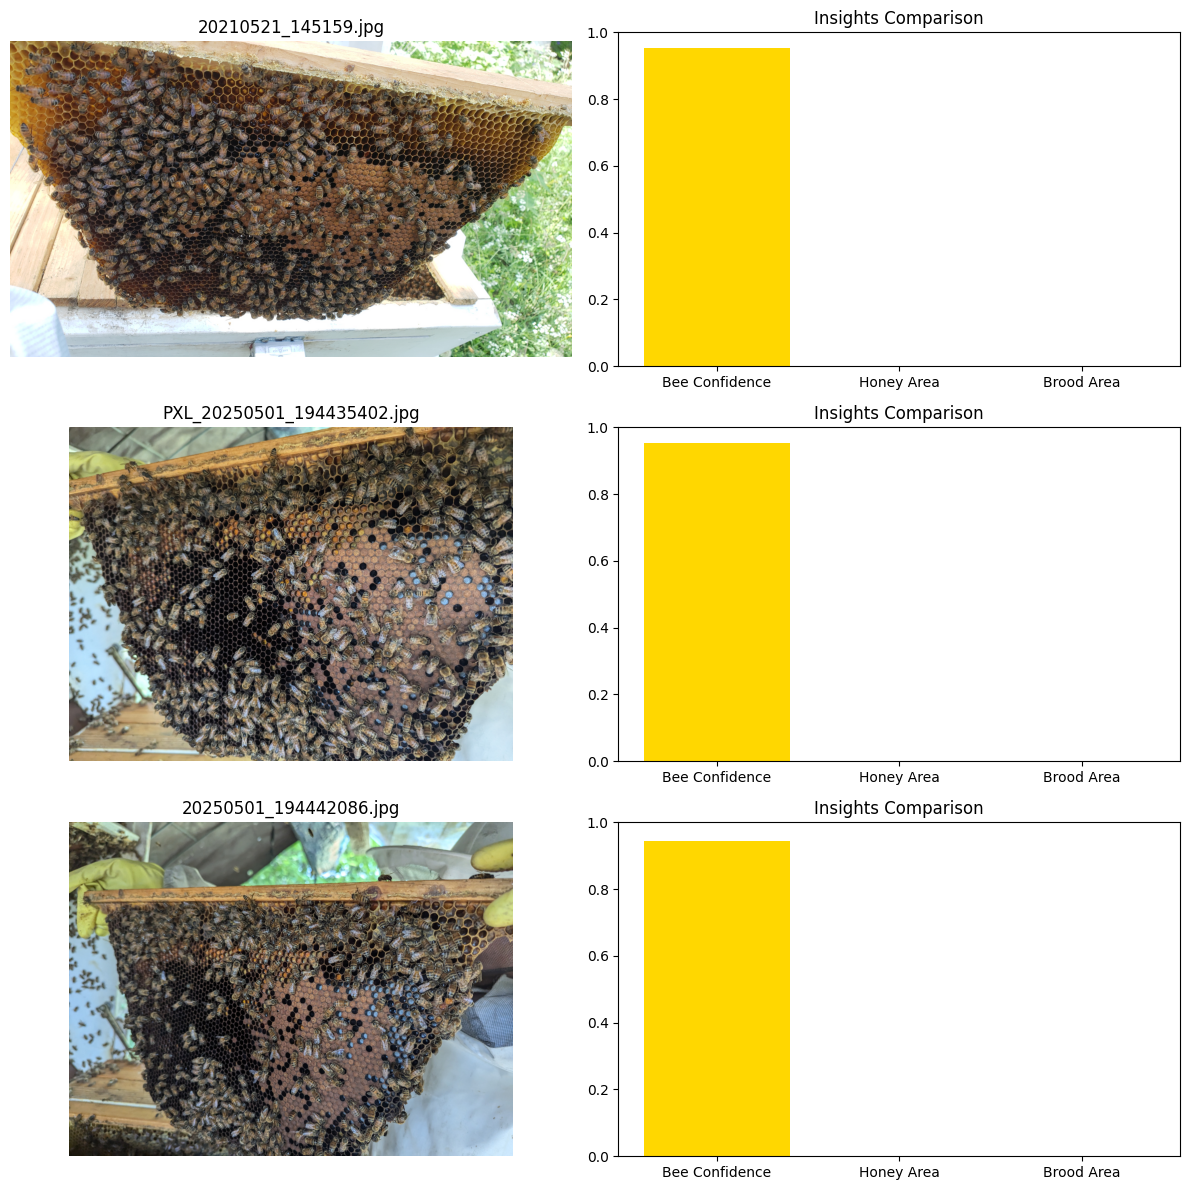

In [9]:
image_list = ["/Users/bhs/Pictures/Bee Photos Over Time/Bees 2021-05-21/20210521_145159.jpg",
             "/Users/bhs/Downloads/PXL_20250501_194435402.jpg", 
             "/Users/bhs/Downloads/20250501_194442086.jpg"]

explorer, comparison_df = compare_images(image_list, credentials_path)


🔍 Analyzing: 20250501_194442086.jpg
  📍 Object Localization...
    Found 1 objects
  🏷️  Label Detection...
    Found 10 labels
  📝 Text Detection...
    Found 4 text elements
  ✂️  Crop Hints...
    Found 1 crop suggestions
  🎨 Image Properties...
    Error in image properties: Unknown field for ImageProperties: dominant_colors_annotation
  🌐 Web Detection...
    Found 2 web entities


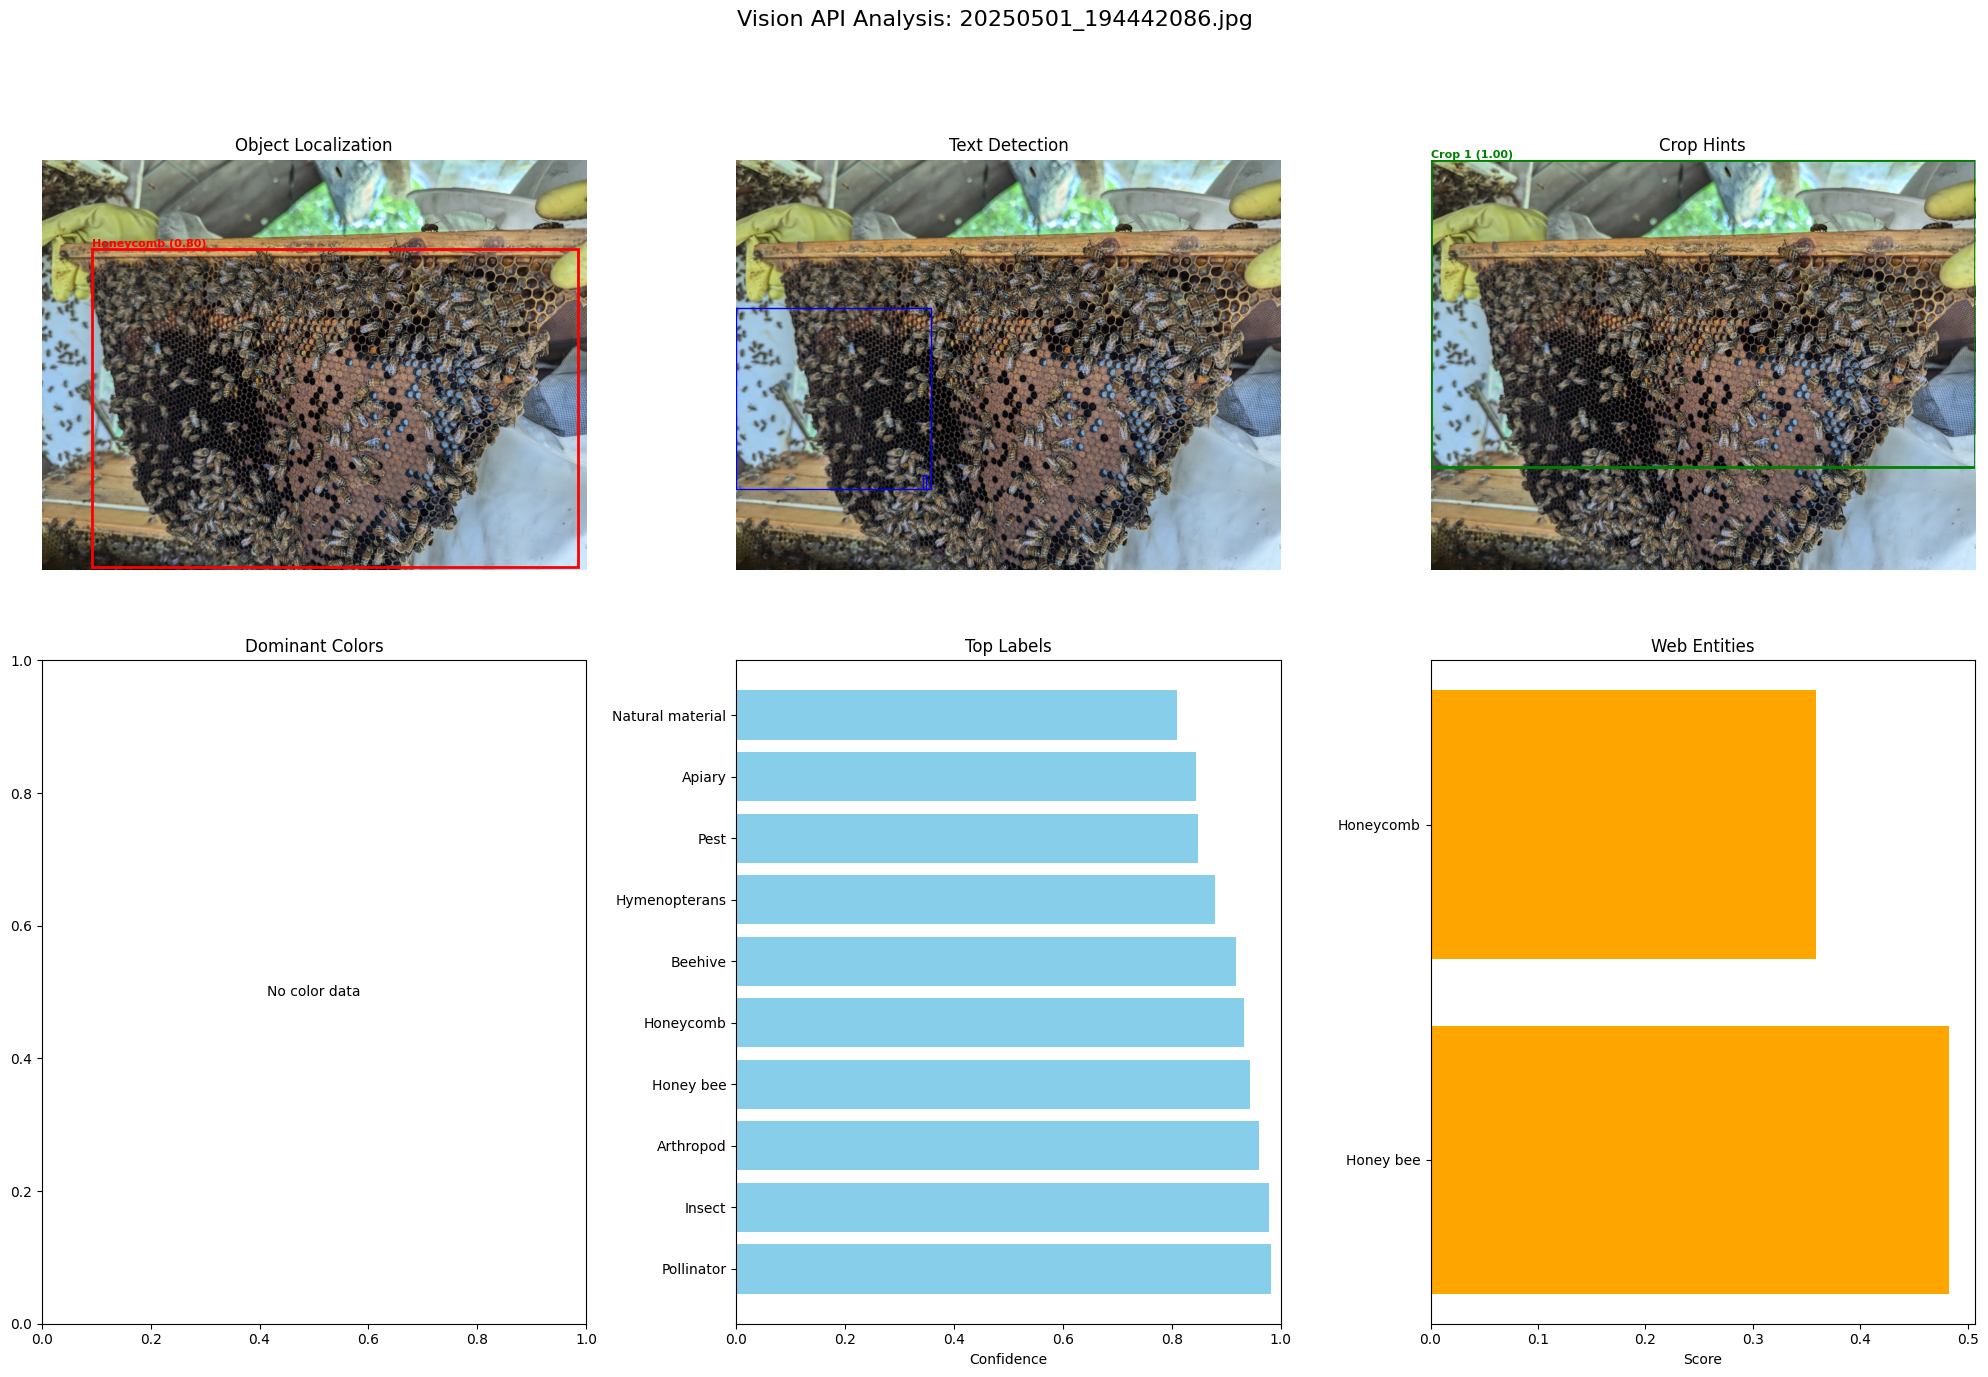

In [10]:
detailed_hive_photo = "/Users/bhs/Downloads/20250501_194442086.jpg"
explorer = BeehiveVisionExplorer(credentials_path, verbose=True)
results = explorer.analyze_comprehensive(detailed_hive_photo)

explorer.visualize_detections(detailed_hive_photo)


In [ ]:
results

### Code to support above function calls:

In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from google.cloud import vision
from typing import List, Dict, Any
import base64
from pathlib import Path
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for notebooks
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'

class BeehiveVisionExplorer:
    """
    Comprehensive exploration tool for Google Cloud Vision API capabilities
    focused on beehive and honeycomb analysis
    """
    
    def __init__(self, credentials_path: str = None, verbose: bool = True):
        """Initialize the Vision API client"""
        if credentials_path:
            os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = credentials_path
        
        self.client = vision.ImageAnnotatorClient()
        self.results = {}
        self.verbose = verbose  # Control output verbosity for notebooks
        
    def load_image(self, image_path: str) -> vision.Image:
        """Load image for Vision API processing"""
        with open(image_path, 'rb') as image_file:
            content = image_file.read()
        return vision.Image(content=content)
    
    def analyze_comprehensive(self, image_path: str) -> Dict[str, Any]:
        """
        Run comprehensive analysis using all available Vision API features
        """
        if self.verbose:
            print(f"🔍 Analyzing: {Path(image_path).name}")
        image = self.load_image(image_path)
        
        results = {
            'image_path': image_path,
            'analysis': {}
        }
        
        # 1. OBJECT LOCALIZATION - Can it detect specific hive components?
        if self.verbose:
            print("  📍 Object Localization...")
        try:
            objects = self.client.object_localization(image=image).localized_object_annotations
            results['analysis']['objects'] = [
                {
                    'name': obj.name,
                    'confidence': obj.score,
                    'bounding_box': [(vertex.x, vertex.y) for vertex in obj.bounding_poly.normalized_vertices]
                } for obj in objects
            ]
            if self.verbose:
                print(f"    Found {len(objects)} objects")
        except Exception as e:
            if self.verbose:
                print(f"    Error in object localization: {e}")
            results['analysis']['objects'] = []
        
        # 2. LABEL DETECTION - General classification
        if self.verbose:
            print("  🏷️  Label Detection...")
        try:
            labels = self.client.label_detection(image=image).label_annotations
            results['analysis']['labels'] = [
                {
                    'description': label.description,
                    'confidence': label.score,
                    'topicality': label.topicality
                } for label in labels[:20]  # Top 20 labels
            ]
            if self.verbose:
                print(f"    Found {len(labels)} labels")
        except Exception as e:
            if self.verbose:
                print(f"    Error in label detection: {e}")
            results['analysis']['labels'] = []
        
        # 3. TEXT DETECTION - Any text in images (dates, notes, etc.)
        if self.verbose:
            print("  📝 Text Detection...")
        try:
            texts = self.client.text_detection(image=image).text_annotations
            results['analysis']['text'] = [
                {
                    'text': text.description,
                    'confidence': text.confidence if hasattr(text, 'confidence') else None,
                    'bounding_box': [(vertex.x, vertex.y) for vertex in text.bounding_poly.vertices]
                } for text in texts
            ]
            if self.verbose:
                print(f"    Found {len(texts)} text elements")
        except Exception as e:
            if self.verbose:
                print(f"    Error in text detection: {e}")
            results['analysis']['text'] = []
        
        # 4. CROP HINTS - Optimal cropping for focus areas
        if self.verbose:
            print("  ✂️  Crop Hints...")
        try:
            crop_hints = self.client.crop_hints(image=image).crop_hints_annotation.crop_hints
            results['analysis']['crop_hints'] = [
                {
                    'confidence': hint.confidence,
                    'importance_fraction': hint.importance_fraction,
                    'bounding_box': [(vertex.x, vertex.y) for vertex in hint.bounding_poly.vertices]
                } for hint in crop_hints
            ]
            if self.verbose:
                print(f"    Found {len(crop_hints)} crop suggestions")
        except Exception as e:
            if self.verbose:
                print(f"    Error in crop hints: {e}")
            results['analysis']['crop_hints'] = []
        
        # 5. IMAGE PROPERTIES - Colors and dominant features
        if self.verbose:
            print("  🎨 Image Properties...")
        try:
            props = self.client.image_properties(image=image).image_properties_annotation
            results['analysis']['properties'] = {
                'dominant_colors': [
                    {
                        'color': {
                            'red': color.color.red,
                            'green': color.color.green,
                            'blue': color.color.blue
                        },
                        'score': color.score,
                        'pixel_fraction': color.pixel_fraction
                    } for color in props.dominant_colors_annotation.colors
                ]
            }
            if self.verbose:
                print(f"    Found {len(props.dominant_colors_annotation.colors)} dominant colors")
        except Exception as e:
            if self.verbose:
                print(f"    Error in image properties: {e}")
            results['analysis']['properties'] = {'dominant_colors': []}
        
        # 6. WEB DETECTION - Similar images and web entities
        if self.verbose:
            print("  🌐 Web Detection...")
        try:
            web = self.client.web_detection(image=image).web_detection
            results['analysis']['web'] = {
                'web_entities': [
                    {
                        'entity_id': entity.entity_id,
                        'description': entity.description,
                        'score': entity.score
                    } for entity in web.web_entities[:10]  # Top 10
                ],
                'best_guess_labels': [label.label for label in web.best_guess_labels],
                'pages_with_matching_images': len(web.pages_with_matching_images),
                'visually_similar_images': len(web.visually_similar_images)
            }
            if self.verbose:
                print(f"    Found {len(web.web_entities)} web entities")
        except Exception as e:
            if self.verbose:
                print(f"    Error in web detection: {e}")
            results['analysis']['web'] = {}
        
        self.results[image_path] = results
        return results
    
    def visualize_detections(self, image_path: str, save_path: str = None):
        """
        Create comprehensive visualization of all detections
        """
        if image_path not in self.results:
            print("Run analysis first!")
            return
        
        results = self.results[image_path]['analysis']
        
        # Load original image
        img = Image.open(image_path)
        fig, axes = plt.subplots(2, 3, figsize=(20, 14))
        fig.suptitle(f'Vision API Analysis: {Path(image_path).name}', fontsize=16)
        
        # 1. Original with object detection
        ax = axes[0, 0]
        ax.imshow(img)
        ax.set_title('Object Localization')
        
        for obj in results.get('objects', []):
            if obj['confidence'] > 0.5:  # Only high-confidence detections
                bbox = obj['bounding_box']
                # Convert normalized coordinates to pixel coordinates
                width, height = img.size
                pixel_bbox = [(x * width, y * height) for x, y in bbox]
                
                # Draw bounding box
                rect = patches.Rectangle(
                    (pixel_bbox[0][0], pixel_bbox[0][1]), 
                    pixel_bbox[2][0] - pixel_bbox[0][0],
                    pixel_bbox[2][1] - pixel_bbox[0][1],
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(pixel_bbox[0][0], pixel_bbox[0][1] - 10, 
                       f"{obj['name']} ({obj['confidence']:.2f})", 
                       color='red', fontsize=8, weight='bold')
        ax.axis('off')
        
        # 2. Text detection
        ax = axes[0, 1]
        ax.imshow(img)
        ax.set_title('Text Detection')
        
        for text in results.get('text', []):
            if len(text['text'].strip()) > 2:  # Skip single characters
                bbox = text['bounding_box']
                rect = patches.Rectangle(
                    (bbox[0][0], bbox[0][1]), 
                    bbox[2][0] - bbox[0][0],
                    bbox[2][1] - bbox[0][1],
                    linewidth=1, edgecolor='blue', facecolor='none'
                )
                ax.add_patch(rect)
        ax.axis('off')
        
        # 3. Crop hints
        ax = axes[0, 2]
        ax.imshow(img)
        ax.set_title('Crop Hints')
        
        for i, hint in enumerate(results.get('crop_hints', [])):
            bbox = hint['bounding_box']
            rect = patches.Rectangle(
                (bbox[0][0], bbox[0][1]), 
                bbox[2][0] - bbox[0][0],
                bbox[2][1] - bbox[0][1],
                linewidth=2, edgecolor='green', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(bbox[0][0], bbox[0][1] - 10, 
                   f"Crop {i+1} ({hint['confidence']:.2f})", 
                   color='green', fontsize=8, weight='bold')
        ax.axis('off')
        
        # 4. Dominant colors
        ax = axes[1, 0]
        colors = results.get('properties', {}).get('dominant_colors', [])
        if colors:
            color_data = []
            for color in colors[:10]:  # Top 10 colors
                rgb = (color['color']['red']/255, color['color']['green']/255, color['color']['blue']/255)
                color_data.append((rgb, color['pixel_fraction'], color['score']))
            
            # Create color bar
            y_pos = np.arange(len(color_data))
            fractions = [c[1] for c in color_data]
            colors_rgb = [c[0] for c in color_data]
            
            bars = ax.barh(y_pos, fractions, color=colors_rgb)
            ax.set_xlabel('Pixel Fraction')
            ax.set_title('Dominant Colors')
            ax.set_yticks(y_pos)
            ax.set_yticklabels([f"Color {i+1}" for i in range(len(color_data))])
        else:
            ax.text(0.5, 0.5, 'No color data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Dominant Colors')
        
        # 5. Labels (top 10)
        ax = axes[1, 1]
        labels = results.get('labels', [])[:10]
        if labels:
            label_names = [label['description'] for label in labels]
            confidences = [label['confidence'] for label in labels]
            
            y_pos = np.arange(len(label_names))
            bars = ax.barh(y_pos, confidences, color='skyblue')
            ax.set_xlabel('Confidence')
            ax.set_title('Top Labels')
            ax.set_yticks(y_pos)
            ax.set_yticklabels(label_names)
            ax.set_xlim(0, 1)
        else:
            ax.text(0.5, 0.5, 'No labels detected', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Top Labels')
        
        # 6. Web entities
        ax = axes[1, 2]
        web_entities = results.get('web', {}).get('web_entities', [])[:8]
        if web_entities:
            entity_names = [entity.get('description', 'Unknown')[:15] for entity in web_entities]
            scores = [entity['score'] for entity in web_entities]
            
            y_pos = np.arange(len(entity_names))
            bars = ax.barh(y_pos, scores, color='orange')
            ax.set_xlabel('Score')
            ax.set_title('Web Entities')
            ax.set_yticks(y_pos)
            ax.set_yticklabels(entity_names)
        else:
            ax.text(0.5, 0.5, 'No web entities', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Web Entities')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Visualization saved to {save_path}")
        
        plt.show()
    
    def generate_report(self, output_file: str = 'vision_analysis_report.json'):
        """Generate comprehensive JSON report of all analyses"""
        report = {
            'summary': {
                'total_images_analyzed': len(self.results),
                'images': list(self.results.keys())
            },
            'detailed_results': self.results
        }
        
        with open(output_file, 'w') as f:
            json.dump(report, f, indent=2, default=str)
        
        print(f"📊 Report saved to {output_file}")
        return report
    
    def analyze_for_beekeeping_insights(self, image_path: str) -> Dict[str, Any]:
        """
        Specialized analysis focusing on beekeeping-relevant insights
        """
        if image_path not in self.results:
            print("Run comprehensive analysis first!")
            return {}
        
        results = self.results[image_path]['analysis']
        
        # Analyze labels for bee-related content
        bee_related_labels = []
        for label in results.get('labels', []):
            description = label['description'].lower()
            if any(keyword in description for keyword in 
                   ['bee', 'hive', 'honey', 'comb', 'wax', 'cell', 'insect', 'hexagon']):
                bee_related_labels.append(label)
        
        # Analyze colors for potential honey/brood indicators
        colors = results.get('properties', {}).get('dominant_colors', [])
        honey_colors = []  # Yellows, ambers, browns
        brood_colors = []  # Whites, pale colors
        wax_colors = []    # Light yellows, whites
        
        for color in colors:
            r, g, b = color['color']['red'], color['color']['green'], color['color']['blue']
            
            # Simple heuristics for color classification
            if r > 200 and g > 150 and b < 100:  # Honey-like colors
                honey_colors.append(color)
            elif r > 200 and g > 200 and b > 200:  # Light/white colors (potential brood)
                brood_colors.append(color)
            elif r > 230 and g > 200 and b < 150:  # Wax-like colors
                wax_colors.append(color)
        
        # Check for geometric patterns (hexagonal cells)
        geometric_labels = [label for label in results.get('labels', []) 
                          if 'hexagon' in label['description'].lower() or 
                             'pattern' in label['description'].lower()]
        
        insights = {
            'bee_related_confidence': sum(label['confidence'] for label in bee_related_labels) / len(bee_related_labels) if bee_related_labels else 0,
            'bee_related_labels': bee_related_labels,
            'potential_honey_area': sum(color['pixel_fraction'] for color in honey_colors),
            'potential_brood_area': sum(color['pixel_fraction'] for color in brood_colors),
            'potential_wax_area': sum(color['pixel_fraction'] for color in wax_colors),
            'geometric_patterns': geometric_labels,
            'color_diversity': len(colors),
            'dominant_color_analysis': {
                'honey_colors': len(honey_colors),
                'brood_colors': len(brood_colors),
                'wax_colors': len(wax_colors)
            }
        }
        
        return insights
    
    def create_summary_dataframe(self) -> pd.DataFrame:
        """
        Create a pandas DataFrame summary of all analyzed images
        Perfect for notebook exploration and filtering
        """
        summary_data = []
        
        for image_path, result in self.results.items():
            analysis = result['analysis']
            insights = self.analyze_for_beekeeping_insights(image_path)
            
            summary_data.append({
                'image_name': Path(image_path).name,
                'image_path': image_path,
                'objects_detected': len(analysis.get('objects', [])),
                'labels_count': len(analysis.get('labels', [])),
                'text_elements': len(analysis.get('text', [])),
                'dominant_colors': len(analysis.get('properties', {}).get('dominant_colors', [])),
                'bee_confidence': insights.get('bee_related_confidence', 0),
                'honey_area': insights.get('potential_honey_area', 0),
                'brood_area': insights.get('potential_brood_area', 0),
                'wax_area': insights.get('potential_wax_area', 0),
                'top_label': analysis.get('labels', [{}])[0].get('description', 'None') if analysis.get('labels') else 'None',
                'top_label_confidence': analysis.get('labels', [{}])[0].get('confidence', 0) if analysis.get('labels') else 0
            })
        
        return pd.DataFrame(summary_data)
    
    def quick_visual_summary(self, image_path: str):
        """
        Quick visual summary optimized for notebook display
        """
        if image_path not in self.results:
            print("Run analysis first!")
            return
        
        results = self.results[image_path]['analysis']
        insights = self.analyze_for_beekeeping_insights(image_path)
        
        # Create a compact 2x2 visualization
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(f'Quick Analysis: {Path(image_path).name}', fontsize=14)
        
        # Original image with objects
        img = Image.open(image_path)
        ax = axes[0, 0]
        ax.imshow(img)
        ax.set_title(f'Objects Detected: {len(results.get("objects", []))}')
        ax.axis('off')
        
        # Top labels
        ax = axes[0, 1]
        labels = results.get('labels', [])[:8]
        if labels:
            y_pos = np.arange(len(labels))
            confidences = [label['confidence'] for label in labels]
            bars = ax.barh(y_pos, confidences, color='lightblue')
            ax.set_yticks(y_pos)
            ax.set_yticklabels([label['description'][:15] for label in labels], fontsize=9)
            ax.set_xlabel('Confidence')
            ax.set_title('Top Labels')
        else:
            ax.text(0.5, 0.5, 'No labels', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Top Labels')
        
        # Beekeeping insights
        ax = axes[1, 0]
        insight_names = ['Bee Confidence', 'Honey Area', 'Brood Area', 'Wax Area']
        insight_values = [
            insights.get('bee_related_confidence', 0),
            insights.get('potential_honey_area', 0),
            insights.get('potential_brood_area', 0),
            insights.get('potential_wax_area', 0)
        ]
        bars = ax.bar(insight_names, insight_values, color=['gold', 'orange', 'lightcoral', 'wheat'])
        ax.set_ylabel('Score/Fraction')
        ax.set_title('Beekeeping Insights')
        ax.tick_params(axis='x', rotation=45)
        
        # Color analysis
        ax = axes[1, 1]
        colors = results.get('properties', {}).get('dominant_colors', [])[:6]
        if colors:
            fractions = [c['pixel_fraction'] for c in colors]
            color_patches = [(c['color']['red']/255, c['color']['green']/255, c['color']['blue']/255) for c in colors]
            bars = ax.bar(range(len(colors)), fractions, color=color_patches)
            ax.set_xlabel('Color Index')
            ax.set_ylabel('Pixel Fraction')
            ax.set_title('Dominant Colors')
        else:
            ax.text(0.5, 0.5, 'No color data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Dominant Colors')
        
        plt.tight_layout()
        plt.show()
        
        # Print key insights
        print(f"\n🐝 Key Insights for {Path(image_path).name}:")
        print(f"   • Bee-related confidence: {insights.get('bee_related_confidence', 0):.2f}")
        print(f"   • Objects detected: {len(results.get('objects', []))}")
        print(f"   • Top label: {results.get('labels', [{}])[0].get('description', 'None')}")
        if results.get('labels'):
            print(f"   • Label confidence: {results.get('labels', [{}])[0].get('confidence', 0):.2f}")

# -----------------------------------------------------------------------------------------
# Notebook-optimized convenience functions
# -----------------------------------------------------------------------------------------

def quick_analysis(image_path: str, credentials_path: str = None, verbose: bool = False):
    """
    Quick analysis perfect for notebook exploration
    """
    explorer = BeehiveVisionExplorer(credentials_path, verbose=verbose)
    results = explorer.analyze_comprehensive(image_path)
    explorer.quick_visual_summary(image_path)
    return explorer, results

def compare_images(image_paths: List[str], credentials_path: str = None):
    """
    Compare multiple images side by side - great for notebook exploration
    """
    explorer = BeehiveVisionExplorer(credentials_path, verbose=False)
    
    print(f"Analyzing {len(image_paths)} images...")
    for path in image_paths:
        explorer.analyze_comprehensive(path)
    
    # Create comparison dataframe
    df = explorer.create_summary_dataframe()
    display(df)
    
    # Visual comparison
    fig, axes = plt.subplots(len(image_paths), 2, figsize=(12, 4*len(image_paths)))
    if len(image_paths) == 1:
        axes = axes.reshape(1, -1)
    
    for i, image_path in enumerate(image_paths):
        # Show image
        img = Image.open(image_path)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{Path(image_path).name}')
        axes[i, 0].axis('off')
        
        # Show insights bar chart
        insights = explorer.analyze_for_beekeeping_insights(image_path)
        insight_values = [
            insights.get('bee_related_confidence', 0),
            insights.get('potential_honey_area', 0),
            insights.get('potential_brood_area', 0),
        ]
        axes[i, 1].bar(['Bee Confidence', 'Honey Area', 'Brood Area'], 
                      insight_values, color=['gold', 'orange', 'lightcoral'])
        axes[i, 1].set_ylim(0, 1)
        axes[i, 1].set_title('Insights Comparison')
    
    plt.tight_layout()
    plt.show()
    
    return explorer, df

# Quick Start Examples for Jupyter Notebook

def notebook_quick_start():
    """
    Display quick start guide for notebook users
    """
    from IPython.display import display, Markdown
    
    guide = """
    # 🐝 Vision API Explorer - Notebook Quick Start
    
    ## Setup (Run Once)
    ```python
    # Set your credentials
    credentials_path = "path/to/your-service-account-key.json"
    
    # Or set environment variable
    import os
    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = credentials_path
    ```
    
    ## Quick Single Image Analysis
    ```python
    # Analyze one image with minimal output
    explorer, results = quick_analysis('path/to/hive_photo.jpg', verbose=False)
    ```
    
    ## Compare Multiple Images
    ```python
    # Compare several images side by side
    image_list = ['hive1.jpg', 'hive2.jpg', 'hive3.jpg']
    explorer, df = compare_images(image_list)
    ```
    
    ## Deep Dive Analysis
    ```python
    # Full analysis with all visualizations
    explorer = BeehiveVisionExplorer(verbose=True)
    results = explorer.analyze_comprehensive('detailed_hive_photo.jpg')
    explorer.visualize_detections('detailed_hive_photo.jpg')
    
    # Get summary dataframe
    df = explorer.create_summary_dataframe()
    display(df)
    ```
    
    ## Key Questions to Explore
    - Can it distinguish honey vs brood by color?
    - Does it detect hexagonal patterns?
    - What confidence levels do bee-related labels get?
    - How consistent are results across different lighting?
    """
    
    display(Markdown(guide))

# Test scenarios specifically for notebook exploration
def create_test_scenarios_df():
    """
    Create a DataFrame of test scenarios to track your findings
    """
    scenarios = [
        {"scenario": "Capped honey detection", "test_description": "Can it identify sealed honey cells?", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Brood stage identification", "test_description": "Different stages of larval development", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Queen bee detection", "test_description": "Can it spot the queen among workers?", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Bee counting", "test_description": "Accurate count of individual bees", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Disease detection", "test_description": "Abnormal or diseased cells", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Pollen vs honey stores", "test_description": "Distinguish different storage types", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Drone vs worker cells", "test_description": "Different cell sizes and shapes", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Mite detection", "test_description": "Varroa mites on bees", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Hexagonal pattern recognition", "test_description": "Geometric cell structure", "result": "", "confidence": "", "notes": ""},
        {"scenario": "Frame condition assessment", "test_description": "Old vs new comb quality", "result": "", "confidence": "", "notes": ""}
    ]
    
    df = pd.DataFrame(scenarios)
    print("📋 Test Scenarios Tracking Sheet")
    print("Use this DataFrame to track your exploration results:")
    display(df)
    return df
    

In [13]:
# if __name__ == "__main__":
#     # This section won't run in notebooks, but provides standalone script capability
#     print("🐝 Google Cloud Vision API Explorer for Beehive Analysis")
#     print("="*60)
#     print("For Jupyter notebook usage, run: notebook_quick_start()")
    
#     # Display notebook guide
#     notebook_quick_start()

create_test_scenarios_df()

📋 Test Scenarios Tracking Sheet
Use this DataFrame to track your exploration results:


,scenario,test_description,result,confidence,notes
0,Capped honey detection,Can it identify sealed honey cells?,,,
1,Brood stage identification,Different stages of larval development,,,
2,Queen bee detection,Can it spot the queen among workers?,,,
3,Bee counting,Accurate count of individual bees,,,
4,Disease detection,Abnormal or diseased cells,,,
5,Pollen vs honey stores,Distinguish different storage types,,,
6,Drone vs worker cells,Different cell sizes and shapes,,,
7,Mite detection,Varroa mites on bees,,,
8,Hexagonal pattern recognition,Geometric cell structure,,,
9,Frame condition assessment,Old vs new comb quality,,,


,scenario,test_description,result,confidence,notes
0,Capped honey detection,Can it identify sealed honey cells?,,,
1,Brood stage identification,Different stages of larval development,,,
2,Queen bee detection,Can it spot the queen among workers?,,,
3,Bee counting,Accurate count of individual bees,,,
4,Disease detection,Abnormal or diseased cells,,,
5,Pollen vs honey stores,Distinguish different storage types,,,
6,Drone vs worker cells,Different cell sizes and shapes,,,
7,Mite detection,Varroa mites on bees,,,
8,Hexagonal pattern recognition,Geometric cell structure,,,
9,Frame condition assessment,Old vs new comb quality,,,
